# Flat-CBM Monte Carlo — Variance Inflation & Recovery Phase Transition

Companion to `decay_cbm_features.ipynb` (static identities) and `nonbalanced_flat_cbm.ipynb` (threshold scaling $p^\star(m)$). This notebook validates the **mechanism** behind the V.04 non-balanced bound at fixed $m=1000$, sweeping the sampling rate $p$ and imbalance $\eta$.

**Population matrix** — flat CBM ($\alpha=1$) with
$$S_{ij} = \begin{cases} \rho + \beta_0 & i \neq j,\ \text{same clan} \\ \beta_0 & i,j\ \text{different clans} \end{cases}, \qquad \rho = 0.4,\ \beta_0 = 0.1.$$
Closed-form Fiedler: $v^{(2)}_i = c_A = \sqrt{n_2/(m\, n_1)}$ for $i \in C_1$, $v^{(2)}_i = -c_B = -\sqrt{n_1/(m\, n_2)}$ for $i \in C_2$ (with $n_2 \ge n_1 \Rightarrow c_B \le c_A$).

**Empirical estimator** — symmetric Bernoulli mask $\Omega \sim \mathrm{Ber}(p)$ on the strict upper triangle, IPW debiased:
$$\hat S_{ij} = \tfrac{1}{p}\,\Omega_{ij}\, S_{ij}\ (i\neq j), \qquad \hat S_{ii} = S_{ii}.$$
Laplacian error $E_L = \hat L - L = (\hat D - D) - (\hat S - S)$; noise vector $X = E_L\, v^{(2)}$.

**Three checks:**
1. **Variance:** $\mathrm{Var}(X_B) \stackrel{?}{=} \sigma_B^2 = \tfrac{1-p}{p}\,\tfrac{(1+\eta)}{\eta}\,\beta_0^2$ on log-log axes.
2. **Phase transition:** $\Pr[\|\hat v^{(2)} - v^{(2)}\|_\infty < c_B]$ vs $p$, one curve per $\eta$.
3. **Dual threat:** $\mu(U) = (1+\eta)/2$ and the gap penalty $\eta\beta_0$ (vs constant $\rho$) — both linear in $\eta$.

Per-trial caching reuses the existing `sweep_trial` scope, so re-runs are free.

## Cell 1 — Configuration

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.parent != ROOT and not (ROOT / "setup.py").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT / "sub_sampled_fielder_vec"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.theoretical_interpretation.utils import (
    build_flat_cbm_S, flat_cbm_population_fiedler,
    compute_fiedler_of_S, subsample_S,
    compute_recovery,
    make_full_key, make_subsample_key, get_or_compute_full,
    run_sweep,
)
from src.cache_io import sweep_trial as _scope

M_MC        = 1000
BETA0       = 0.1                    # cross-clan similarity
RHO         = 0.4                    # structural margin S_in - S_out
S_IN        = RHO + BETA0            # 0.5  (within-clan off-diagonal)
S_OUT       = BETA0                  # 0.1  (cross-clan)
ETA_VALUES  = [1, 2, 4, 8, 16, 32]
P_GRID      = np.geomspace(0.005, 0.5, 20)
N_TRIALS    = 50
CACHE_DIR   = PROJECT_ROOT / "cache" / "theoretical_interpretation"

# Margin sanity per η: ρ − η·β₀ flips sign at η* = ρ/β₀ = 4.
# This notebook intentionally sweeps past that crossover so the
# phase transition (plot 2) shows the algebraic-margin collapse.
print(f"m={M_MC}, β₀={BETA0}, ρ={RHO}, S_in={S_IN}, S_out={S_OUT}")
print(f"|P_GRID|={len(P_GRID)}  range=[{P_GRID[0]:.4f}, {P_GRID[-1]:.4f}]")
print(f"N_TRIALS={N_TRIALS}")
print("Margin per η (ρ − η·β₀):")
for eta in ETA_VALUES:
    margin = RHO - eta * BETA0
    flag = "✓ positive" if margin > 0 else "✗ collapsed"
    print(f"  η={eta:>2}: {margin:+.3f}   {flag}")

m=1000, β₀=0.1, ρ=0.4, S_in=0.5, S_out=0.1
|P_GRID|=20  range=[0.0050, 0.5000]
N_TRIALS=50
Margin per η (ρ − η·β₀):
  η= 1: +0.300   ✓ positive
  η= 2: +0.200   ✓ positive
  η= 4: +0.000   ✗ collapsed
  η= 8: -0.400   ✗ collapsed
  η=16: -1.200   ✗ collapsed
  η=32: -2.800   ✗ collapsed


## Cell 2 — Population matrices $S(\eta)$ and closed-form $v^{(2)}$

For each $\eta$: $n_1 = \lfloor m/(1+\eta) \rfloor$, $n_2 = m - n_1$, then build $S$ via `build_flat_cbm_S` and cache `(S, fiedler_full)` under prefix `flat_cbm_mc`. The closed-form `flat_cbm_population_fiedler` is verified against the eigensolver output.

In [2]:
pop_data = {}   # pop_data[eta] = (n1, n2, S, v_pop, full_key)
sanity_rows = []

for eta in ETA_VALUES:
    n1 = M_MC // (1 + int(eta))
    n2 = M_MC - n1
    full_key = make_full_key(
        "flat_cbm_mc", eta=eta, m=M_MC, s_in=S_IN, s_out=S_OUT,
    )

    def builder(n1=n1, n2=n2, full_key=full_key, eta=eta):
        S = build_flat_cbm_S(n1, n2, S_IN, S_OUT)
        fiedler_full = compute_fiedler_of_S(S)
        meta = {
            "tree_model": "flat_cbm_mc",
            "eta": eta, "n1": n1, "n2": n2, "m": M_MC,
            "s_in": S_IN, "s_out": S_OUT, "full_key": full_key,
        }
        return S, fiedler_full, meta

    S, fiedler_full = get_or_compute_full(CACHE_DIR, full_key, builder)
    v_pop = flat_cbm_population_fiedler(n1, n2)
    pop_data[eta] = (n1, n2, S, v_pop, full_key)

    sanity_rows.append({
        "eta": eta, "n1": n1, "n2": n2,
        "c_A": float(np.sqrt(n2 / (M_MC * n1))),
        "c_B": float(np.sqrt(n1 / (M_MC * n2))),
        "sign_agreement": float(compute_recovery(v_pop, fiedler_full)),
    })

df_sanity = pd.DataFrame(sanity_rows)
assert (df_sanity["sign_agreement"] == 1.0).all(), \
    "Closed-form Fiedler disagrees with eigensolver — investigate before sweeping."
print("All closed-form Fiedlers agree with eigensolver ✓")
df_sanity

All closed-form Fiedlers agree with eigensolver ✓


,eta,n1,n2,c_A,c_B,sign_agreement
0,1,500,500,0.031623,0.031623,1.0
1,2,333,667,0.044755,0.022344,1.0
2,4,200,800,0.063246,0.015811,1.0
3,8,111,889,0.089493,0.011174,1.0
4,16,58,942,0.127442,0.007847,1.0
5,32,30,970,0.179815,0.005561,1.0


## Cell 3 — Monte Carlo sweep with per-trial caching

**Stage 1** — `run_sweep` over $(p,\text{seed})$ for each $\eta$, collecting `sign_agreement` and the sign-aligned $L_\infty$ error.

**Stage 2** — for each cached trial, deterministically re-derive $\hat S$ from the seed, compute $\mathrm{Var}((\hat L - L)v^{(2)})$ over Clan B, and merge `var_xB` into the trial's `metrics.json` via `_scope.extend`. Re-running is free.

In [3]:
def inf_error_aligned(v_full: np.ndarray, v_hat: np.ndarray) -> float:
    """Sign-aligned L_inf distance ||sign·v_hat - v_full||_inf, sign chosen to match v_full."""
    sign = 1.0 if float(np.dot(v_full, v_hat)) >= 0.0 else -1.0
    return float(np.max(np.abs(sign * v_hat - v_full)))


def _var_xB_from_seed(S: np.ndarray, v_pop: np.ndarray, n1: int,
                     p: float, seed: int) -> float:
    S_hat = subsample_S(S, p, seed)
    delta_S = S_hat - S
    delta_D = delta_S.sum(axis=1)
    X = delta_D * v_pop - delta_S @ v_pop      # (Δ_D − Δ_S) v_pop, Δ_D diagonal
    return float(np.var(X[n1:], ddof=0))


# Stage 1: run_sweep (caches fiedler_hat, sign_agreement, inf_error).
sweep_rows = []
for eta in ETA_VALUES:
    n1, n2, S, v_pop, full_key = pop_data[eta]
    fiedler_full = compute_fiedler_of_S(S)
    df_e = run_sweep(
        CACHE_DIR, full_key, S, fiedler_full, P_GRID, N_TRIALS,
        metrics={
            "sign_agreement": compute_recovery,
            "inf_error":      inf_error_aligned,
        },
        progress=False,
    )
    df_e["eta"] = eta
    df_e["n1"]  = n1
    df_e["n2"]  = n2
    sweep_rows.append(df_e)

df_long = pd.concat(sweep_rows, ignore_index=True)

# Stage 2: extend each cached trial with var_xB (idempotent).
var_rows = []
for eta in ETA_VALUES:
    n1, n2, S, v_pop, full_key = pop_data[eta]
    for p in P_GRID:
        p_f = float(p)
        for seed in range(N_TRIALS):
            sub_key = make_subsample_key(p_f, int(seed))
            cached = _scope.try_load(full_key, sub_key) or {}
            metrics = dict(cached.get("metrics") or {})
            if "var_xB" not in metrics:
                metrics["var_xB"] = _var_xB_from_seed(S, v_pop, n1, p_f, int(seed))
                _scope.extend(full_key, sub_key, metrics=metrics)
            var_rows.append({
                "eta": eta, "p": p_f, "seed": int(seed),
                "var_xB": float(metrics["var_xB"]),
            })

df_var = pd.DataFrame(var_rows)
df_long = df_long.merge(df_var, on=["eta", "p", "seed"], how="left")

# Attach c_B per row for the recovery threshold.
df_long["c_B"] = df_long.apply(
    lambda r: float(np.sqrt(r["n1"] / (M_MC * r["n2"]))), axis=1,
)
df_long["recovered"] = df_long["inf_error"] < df_long["c_B"]

print(f"df_long shape: {df_long.shape}  ({len(ETA_VALUES)}η × {len(P_GRID)}p × {N_TRIALS} trials)")
df_long.head()

df_long shape: (6000, 11)  (6η × 20p × 50 trials)


,full_key,p,seed,sign_agreement,inf_error,eta,n1,n2,var_xB,c_B,recovered
0,flat_cbm_mc_eta0001_m1000_s_in0p5000_s_out0p1000,0.005,0,0.500,0.801812,1,500,500,4.044902,0.031623,False
1,flat_cbm_mc_eta0001_m1000_s_in0p5000_s_out0p1000,0.005,1,0.500,0.757032,1,500,500,4.598342,0.031623,False
2,flat_cbm_mc_eta0001_m1000_s_in0p5000_s_out0p1000,0.005,2,0.501,0.750660,1,500,500,4.233574,0.031623,False
3,flat_cbm_mc_eta0001_m1000_s_in0p5000_s_out0p1000,0.005,3,0.502,0.943950,1,500,500,4.239769,0.031623,False
4,flat_cbm_mc_eta0001_m1000_s_in0p5000_s_out0p1000,0.005,4,0.501,0.880822,1,500,500,3.864441,0.031623,False


## Plot 1 — Empirical vs theoretical noise variance

Solid: mean of $\mathrm{Var}(X_B)$ over trials, shaded $\pm 1\sigma$. Dotted (matching color): theoretical $\sigma_B^2(p,\eta) = \tfrac{1-p}{p}\tfrac{(1+\eta)}{\eta}\beta_0^2$. Solid should track dotted.

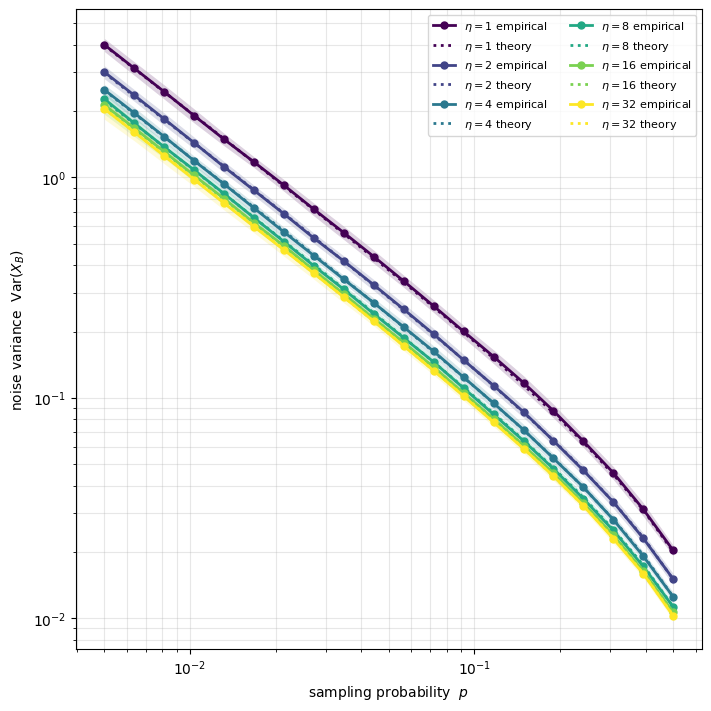

empirical/theory variance ratio (median, min, max) per η:
  η= 1:  median=1.010   range=[0.995, 1.024]
  η= 2:  median=1.002   range=[0.992, 1.009]
  η= 4:  median=1.000   range=[0.988, 1.008]
  η= 8:  median=0.994   range=[0.986, 1.015]
  η=16:  median=1.000   range=[0.993, 1.012]
  η=32:  median=0.997   range=[0.990, 1.002]


In [4]:
agg_var = (df_long.groupby(["eta", "p"], as_index=False)["var_xB"]
                  .agg(mean="mean", std="std"))

cmap = plt.get_cmap("viridis")
eta_to_color = {
    eta: cmap(i / max(1, len(ETA_VALUES) - 1))
    for i, eta in enumerate(ETA_VALUES)
}

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)

ratio_records = []
for eta in ETA_VALUES:
    sub = agg_var[agg_var.eta == eta].sort_values("p")
    p_arr  = sub["p"].to_numpy()
    mean_e = sub["mean"].to_numpy()
    std_e  = sub["std"].to_numpy()
    sigma2 = (1.0 - p_arr) / p_arr * (1.0 + eta) / eta * BETA0**2

    color = eta_to_color[eta]
    ax.fill_between(p_arr, np.clip(mean_e - std_e, 1e-12, None),
                    mean_e + std_e, color=color, alpha=0.18, lw=0)
    ax.plot(p_arr, mean_e, "-o", color=color, lw=2, ms=5,
            label=fr"$\eta={eta}$ empirical")
    ax.plot(p_arr, sigma2, ":", color=color, lw=2,
            label=fr"$\eta={eta}$ theory")

    ratio = mean_e / sigma2
    ratio_records.append((eta, float(np.median(ratio)),
                          float(ratio.min()), float(ratio.max())))

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"sampling probability  $p$")
ax.set_ylabel(r"noise variance  $\mathrm{Var}(X_B)$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, ncol=2, loc="upper right")
plt.show()

print("empirical/theory variance ratio (median, min, max) per η:")
for eta, med, lo, hi in ratio_records:
    print(f"  η={eta:>2}:  median={med:.3f}   range=[{lo:.3f}, {hi:.3f}]")

## Plot 2 — Phase transition of exact $L_\infty$ recovery

Probability over trials that $\|\hat v^{(2)} - v^{(2)}\|_\infty < c_B$, one curve per $\eta$. Expected: waterfall shifts right with $\eta$.

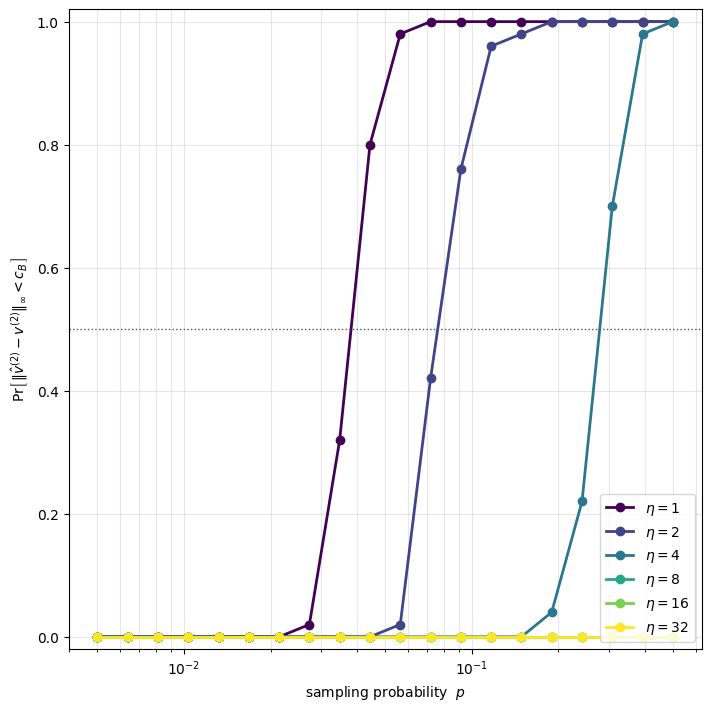

In [5]:
agg_rec = (df_long.groupby(["eta", "p"], as_index=False)["recovered"]
                  .mean()
                  .rename(columns={"recovered": "prob"}))

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
for eta in ETA_VALUES:
    sub = agg_rec[agg_rec.eta == eta].sort_values("p")
    ax.plot(sub["p"], sub["prob"], "-o", color=eta_to_color[eta],
            lw=2, ms=6, label=fr"$\eta={eta}$")

ax.axhline(0.5, color="#4b5563", ls=":", lw=1)
ax.set_xscale("log")
ax.set_xlabel(r"sampling probability  $p$")
ax.set_ylabel(r"$\Pr\!\left[\,\|\hat v^{(2)} - v^{(2)}\|_\infty < c_B\,\right]$")
ax.set_ylim(-0.02, 1.02)
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=10, loc="lower right")
plt.show()

## Plot 3 — The dual threat: coherence and gap penalty

Both terms grow linearly in $\eta$:
- **Left axis** — coherence $\mu(U) = (1+\eta)/2$ amplifies sampling noise.
- **Right axis** — algebraic penalty $\eta\beta_0$ against constant structural margin $\rho$. They cross at $\eta^\star = \rho/\beta_0 = 4$; beyond, the population gap collapses.

This visualizes *why* recovery degrades with $\eta$ — even before sampling, the bound's denominator is shrinking.

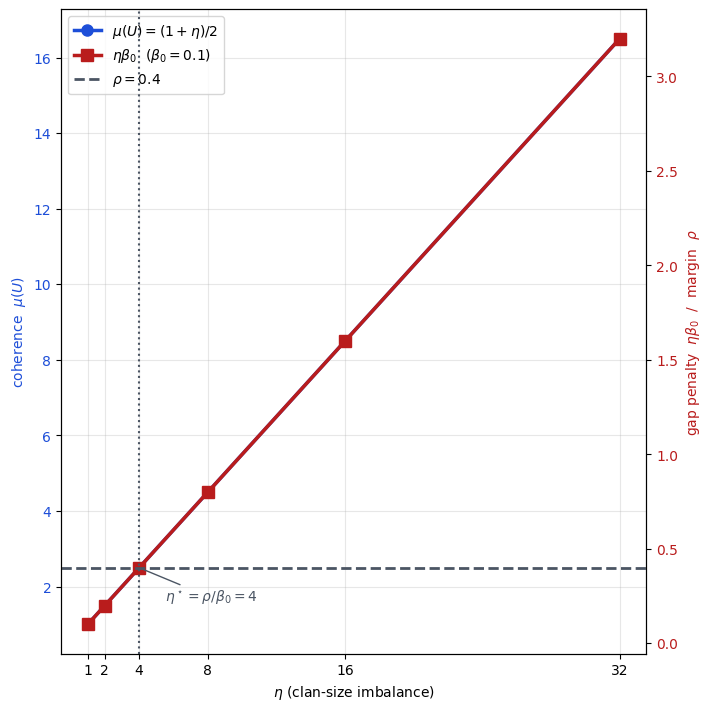

In [6]:
eta_grid = np.array(ETA_VALUES, dtype=float)
mu_U     = (1.0 + eta_grid) / 2.0
penalty  = eta_grid * BETA0
eta_star = RHO / BETA0           # = 4

COLOR_MU      = "#1d4ed8"   # blue
COLOR_PENALTY = "#b91c1c"   # red
COLOR_RHO     = "#4b5563"   # gray

fig, ax_l = plt.subplots(figsize=(7, 7), constrained_layout=True)
ax_r = ax_l.twinx()

ax_l.plot(eta_grid, mu_U, "-o", color=COLOR_MU, lw=2.5, ms=8,
          label=r"$\mu(U) = (1+\eta)/2$")
ax_l.set_xlabel(r"$\eta$ (clan-size imbalance)")
ax_l.set_ylabel(r"coherence  $\mu(U)$", color=COLOR_MU)
ax_l.tick_params(axis="y", labelcolor=COLOR_MU)

ax_r.plot(eta_grid, penalty, "-s", color=COLOR_PENALTY, lw=2.5, ms=8,
          label=fr"$\eta\beta_0$  ($\beta_0={BETA0}$)")
ax_r.axhline(RHO, color=COLOR_RHO, ls="--", lw=2,
             label=fr"$\rho = {RHO}$")
ax_r.axvline(eta_star, color=COLOR_RHO, ls=":", lw=1.5)
ax_r.annotate(fr"$\eta^\star = \rho/\beta_0 = {eta_star:.0f}$",
              xy=(eta_star, RHO), xytext=(eta_star + 1.5, RHO * 0.55),
              fontsize=10, color=COLOR_RHO,
              arrowprops=dict(arrowstyle="-", color=COLOR_RHO, lw=1))
ax_r.set_ylabel(r"gap penalty  $\eta\beta_0$  /  margin  $\rho$",
                color=COLOR_PENALTY)
ax_r.tick_params(axis="y", labelcolor=COLOR_PENALTY)

ax_l.set_xticks(ETA_VALUES)
ax_l.grid(True, alpha=0.3)

lines_l, labels_l = ax_l.get_legend_handles_labels()
lines_r, labels_r = ax_r.get_legend_handles_labels()
ax_l.legend(lines_l + lines_r, labels_l + labels_r,
            fontsize=10, loc="upper left")
plt.show()